# Comparativa de técnicas XAI

             NSL-KDD - ranking por lente (1 = mas importante)           
                        shape (EBM)  SHAP (RF)  PI-EBM  PI-RF
src_bytes                         3          1       1      1
service                           1          4       2      2
dst_bytes                         6          2       3      3
dst_host_srv_count                5          3       4      4
dst_host_same_srv_rate            7          7       5      5
same_srv_rate                     4          5       6      7
diff_srv_rate                     8          8       7      8
flag                              2          6       8      6

Spearman entre lentes (1 = consistencia perfecta):
  shape (EBM)  vs SHAP (RF)   : rho = 0.405
  shape (EBM)  vs PI-EBM      : rho = 0.286
  shape (EBM)  vs PI-RF       : rho = 0.476
  SHAP (RF)    vs PI-EBM      : rho = 0.810
  SHAP (RF)    vs PI-RF       : rho = 0.833
  PI-EBM       vs PI-RF       : rho = 0.929


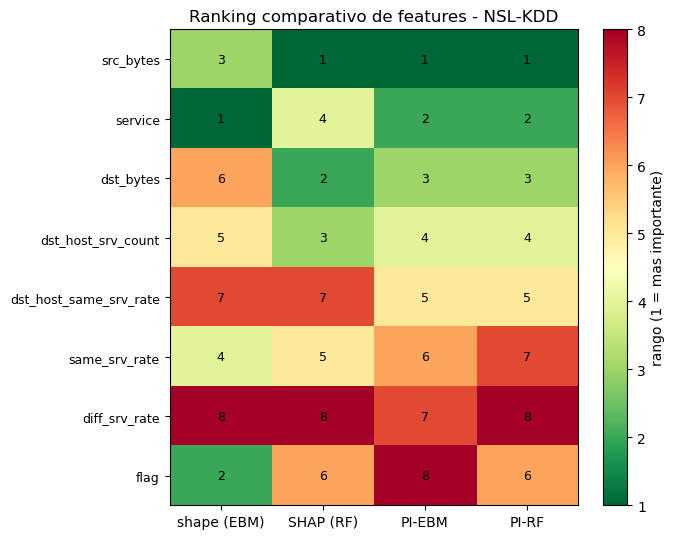


Figura guardada: comparativa_xai_nsl_kdd.png

              Mirai - ranking por lente (1 = mas importante)            
              shape (EBM)  SHAP (RF)  PI-EBM  PI-RF
avg_pkt_size            3          2       1      3
state                   1          1       2      1
n_bytes                 2          4       3      6
f_bytes                 4          3       4      2
n_pkts                  9          7       5      8
f_pkts                  5          9       6      7
duration                6          5       7      4
b_pkts                  7          6       8      9
b_bytes                 8          8       9      5

Spearman entre lentes (1 = consistencia perfecta):
  shape (EBM)  vs SHAP (RF)   : rho = 0.767
  shape (EBM)  vs PI-EBM      : rho = 0.783
  shape (EBM)  vs PI-RF       : rho = 0.650
  SHAP (RF)    vs PI-EBM      : rho = 0.783
  SHAP (RF)    vs PI-RF       : rho = 0.750
  PI-EBM       vs PI-RF       : rho = 0.550


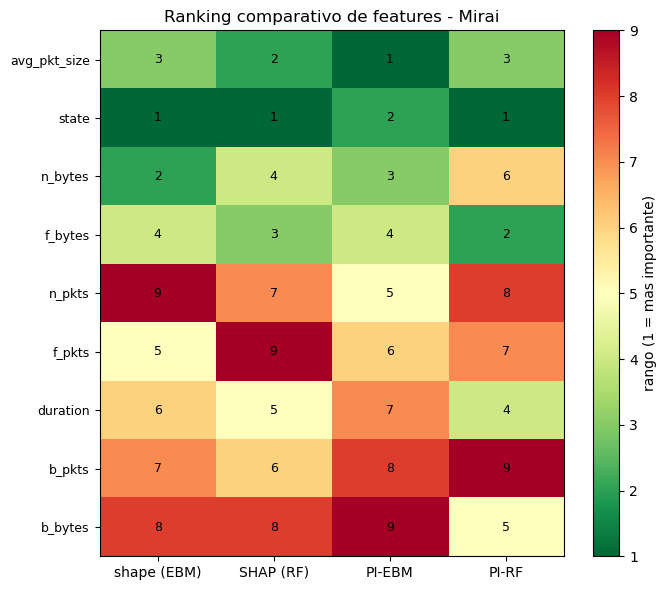


Figura guardada: comparativa_xai_mirai.png

              DS2OS - ranking por lente (1 = mas importante)            
                           shape (EBM)  SHAP (RF)  PI-EBM  PI-RF
sourceID                             1          1       1      1
operation                            2          2       2      2
destinationServiceType               4          7       3      5
accessedNodeType                     5          3       4      3
destinationLocation                  6         11       5      7
sourceAddress                        3          8       6      6
sourceLocation                       7          9       7      8
accessedNodeAddress                  8          5       8     10
sourceType                          10         10       9      9
destinationServiceAddress            9          6      10     11
value                               11          4      11      4

Spearman entre lentes (1 = consistencia perfecta):
  shape (EBM)  vs SHAP (RF)   : rho = 0.391
  shap

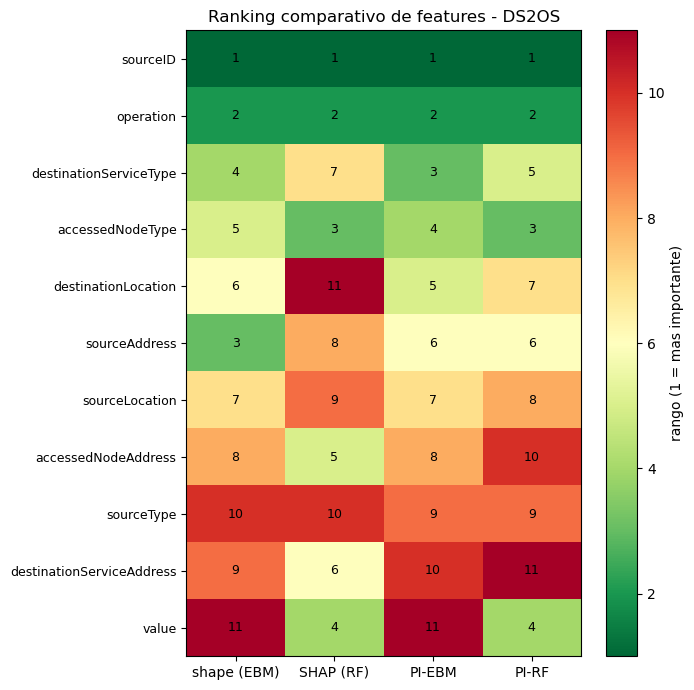


Figura guardada: comparativa_xai_ds2os.png



In [3]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import spearmanr

BASE = Path('C:/Users/user/TFM')
ebm = json.load(open(BASE / 'xai_rankings_ebm.json', encoding='utf-8'))
rf  = json.load(open(BASE / 'xai_rankings_rf.json',  encoding='utf-8'))

DATASETS = ['NSL-KDD', 'Mirai', 'DS2OS']

def ranks_from_values(d):
    order = sorted(d, key=lambda f: d[f], reverse=True)
    return {f: r for r, f in enumerate(order, 1)}

for ds in DATASETS:
    if ds not in ebm or ds not in rf:
        print(f'{ds}: faltan datos, saltado'); continue
    feats = list(ebm[ds].keys())
    lentes = {
        'shape (EBM)': {f: ebm[ds][f]['shape']       for f in feats},
        'SHAP (RF)':   {f: rf[ds][f]['shap']          for f in feats},
        'PI-EBM':      {f: ebm[ds][f]['pi_ebm_mean']  for f in feats},
        'PI-RF':       {f: rf[ds][f]['pi_rf_mean']    for f in feats},
    }
    ranks = {k: ranks_from_values(v) for k, v in lentes.items()}
    df = pd.DataFrame({k: [ranks[k][f] for f in feats] for k in lentes}, index=feats)
    df = df.sort_values('PI-EBM')

    print('=' * 72)
    print(f'  {ds} - ranking por lente (1 = mas importante)'.center(72))
    print('=' * 72)
    print(df.to_string())

    # Consistencia entre lentes (Spearman sobre TODAS las features).
    # Nota: en datasets de baja dimension efectiva (Mirai, solo ~3 features con
    # senal real) un rho moderado NO implica desacuerdo: las features con
    # importancia ~0 tienen orden casi aleatorio y penalizan la correlacion global.
    keys = list(lentes.keys())
    print('\nSpearman entre lentes (1 = consistencia perfecta):')
    for a in range(len(keys)):
        for b in range(a + 1, len(keys)):
            va = [lentes[keys[a]][f] for f in feats]
            vb = [lentes[keys[b]][f] for f in feats]
            rho = spearmanr(va, vb).correlation
            print(f'  {keys[a]:<12} vs {keys[b]:<12}: rho = {rho:.3f}')

    M = df.values
    fig, ax = plt.subplots(figsize=(7, 0.5 * len(df) + 1.5))
    im = ax.imshow(M, cmap='RdYlGn_r', aspect='auto')
    ax.set_xticks(range(len(df.columns))); ax.set_xticklabels(df.columns, fontsize=10)
    ax.set_yticks(range(len(df.index)));   ax.set_yticklabels(df.index, fontsize=9)
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            ax.text(j, i, int(M[i, j]), ha='center', va='center', fontsize=9)
    ax.set_title(f'Ranking comparativo de features - {ds}', fontsize=12)
    plt.colorbar(im, ax=ax, label='rango (1 = mas importante)')
    plt.tight_layout()
    fname = f'comparativa_xai_{ds.lower().replace(chr(45), chr(95))}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'\nFigura guardada: {fname}\n')
